# Stability of PPS Noise Radius Across Windows and Sessions

Đánh giá độ ổn định của `rho*` trên Session 1 và một session replication,
theo representation, trạng thái và độ dài cửa sổ. Notebook chỉ thực hiện
rho optimization; không sinh ensemble cuối hoặc surrogate hypothesis test.


In [1]:
# TASK 1 - Imports and frozen configuration
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from joblib import Parallel, delayed
from scipy.spatial import cKDTree


def find_project_root():
    '''Locate the repository root.'''
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "phase1"))

from src.dataloader.loader import load_segmented_session
from src.surrogates.pps import embed_phase_space, optimize_rho

SESSIONS = ("sample_1.csv", "sample_10.csv")
SESSION_NAMES = {
    "sample_1.csv": "Session 1",
    "sample_10.csv": "Session 10",
}
WINDOW_SIZES = (60, 120, 180)
REPRESENTATIONS = ("Processed", "Raw")
STATE_NAMES = {0: "Awake", 1: "Drowsy"}
EMBEDDING_DIMENSION = 8
TAU_SECONDS = {"Processed": 0.16, "Raw": 0.20}
SEGMENT_LENGTH = 2
COUNT_MODE = "at_least"
MASTER_SEED = 20_260_825
OPTIMIZATION_TRIALS = 3
N_JOBS = 6
GEOMETRY_PAIRS = 50_000
PLATEAU_FRACTION = 0.95
MAX_BOUNDARY_FRACTION = 0.05
COVERAGE_TARGET = 0.80
MIN_GROUP_COVERAGE = 0.70
SESSION_SHIFT_LIMIT = 0.50

RHO_GRIDS = {
    "Processed": np.geomspace(1.0, 200.0, 21),
    "Raw": np.geomspace(2.0, 500.0, 21),
}

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})
sns.set_theme(style="whitegrid")


In [2]:
# TASK 2 - Load all eligible windows from two sessions
window_records = []
for session in SESSIONS:
    for representation in REPRESENTATIONS:
        batches, metadata = load_segmented_session(
            session,
            window_sizes=WINDOW_SIZES,
            representation=representation.lower(),
            stationarity_only=representation == "Processed",
        )
        for window_size, batch in batches.items():
            for index, signal in enumerate(batch["signal"]):
                label = int(batch["label"][index])
                sampling_rate = float(batch["fs"])
                window_records.append(
                    {
                        "session": SESSION_NAMES[session],
                        "session_file": session,
                        "representation": representation,
                        "state": STATE_NAMES[label],
                        "window_size": int(window_size),
                        "window_id": int(batch["window_id"][index]),
                        "N": len(signal),
                        "sampling_rate": sampling_rate,
                        "tau_samples": int(
                            round(
                                TAU_SECONDS[representation]
                                * sampling_rate
                            )
                        ),
                        "signal": np.asarray(signal, dtype=float),
                    }
                )

window_metadata = pd.DataFrame(
    [
        {key: value for key, value in record.items() if key != "signal"}
        for record in window_records
    ]
)
group_counts = (
    window_metadata.groupby(
        ["session", "representation", "state", "window_size"]
    )
    .size()
    .rename("n_windows")
    .reset_index()
)
display(window_metadata)
group_counts


,session,session_file,representation,state,window_size,window_id,N,sampling_rate,tau_samples
0,Session 1,sample_1.csv,Processed,Awake,60,1,3000,50.000000,8
1,Session 1,sample_1.csv,Processed,Awake,60,2,3000,50.000000,8
2,Session 1,sample_1.csv,Processed,Awake,60,3,3000,50.000000,8
3,Session 1,sample_1.csv,Processed,Awake,60,4,3000,50.000000,8
4,Session 1,sample_1.csv,Processed,Awake,60,5,3000,50.000000,8
...,...,...,...,...,...,...,...,...,...
222,Session 10,sample_10.csv,Raw,Awake,180,5,4500,24.998236,5
223,Session 10,sample_10.csv,Raw,Awake,180,6,4500,24.998236,5
224,Session 10,sample_10.csv,Raw,Awake,180,7,4500,24.998236,5
225,Session 10,sample_10.csv,Raw,Awake,180,8,4500,24.998236,5


,session,representation,state,window_size,n_windows
0,Session 1,Processed,Awake,60,24
1,Session 1,Processed,Awake,120,11
2,Session 1,Processed,Awake,180,6
3,Session 1,Processed,Drowsy,60,7
4,Session 1,Processed,Drowsy,120,1
5,Session 1,Processed,Drowsy,180,1
6,Session 1,Raw,Awake,60,24
7,Session 1,Raw,Awake,120,11
8,Session 1,Raw,Awake,180,6
9,Session 1,Raw,Drowsy,60,10


In [3]:
# TASK 3 - Audit window-count comparability
count_table = group_counts.pivot_table(
    index=["session", "representation", "state"],
    columns="window_size",
    values="n_windows",
    fill_value=0,
).reindex(columns=WINDOW_SIZES, fill_value=0)
count_table.columns = [f"{size}_s" for size in count_table.columns]
count_table = count_table.reset_index()
count_table


,session,representation,state,60_s,120_s,180_s
0,Session 1,Processed,Awake,24.0,11.0,6.0
1,Session 1,Processed,Drowsy,7.0,1.0,1.0
2,Session 1,Raw,Awake,24.0,11.0,6.0
3,Session 1,Raw,Drowsy,10.0,3.0,1.0
4,Session 10,Processed,Awake,27.0,12.0,7.0
5,Session 10,Processed,Drowsy,9.0,4.0,2.0
6,Session 10,Raw,Awake,27.0,12.0,7.0
7,Session 10,Raw,Drowsy,9.0,4.0,2.0


In [4]:
# TASK 4 - Define fixed rho grids by representation
rho_grid_summary = pd.DataFrame(
    [
        {
            "representation": representation,
            "rho_min": grid.min(),
            "rho_max": grid.max(),
            "n_candidates": len(grid),
            "log_step_ratio": grid[1] / grid[0],
            "trials_per_rho": OPTIMIZATION_TRIALS,
        }
        for representation, grid in RHO_GRIDS.items()
    ]
)
rho_grid_summary


,representation,rho_min,rho_max,n_candidates,log_step_ratio,trials_per_rho
0,Processed,1.0,200.0,21,1.303321,3
1,Raw,2.0,500.0,21,1.317944,3


In [5]:
# TASK 5 - Optimize rho independently for every eligible window
def optimize_window(record, seed):
    '''Optimize rho and retain the full C2 curve.'''
    grid = RHO_GRIDS[record["representation"]]
    result = optimize_rho(
        signal=record["signal"],
        tau=record["tau_samples"],
        m=EMBEDDING_DIMENSION,
        rho_candidates=grid,
        trials=OPTIMIZATION_TRIALS,
        segment_length=SEGMENT_LENGTH,
        count_mode=COUNT_MODE,
        seed=seed,
    )
    best_index = int(np.argmax(result["mean_counts"]))
    return {
        "session": record["session"],
        "representation": record["representation"],
        "state": record["state"],
        "window_size": record["window_size"],
        "window_id": record["window_id"],
        "rho_star": float(result["optimal_rho"]),
        "peak_C2": float(result["mean_counts"][best_index]),
        "peak_C2_sd": float(result["std_counts"][best_index]),
        "boundary_flag": best_index in {0, len(grid) - 1},
        "best_index": best_index,
        "rho_candidates": result["rho_candidates"],
        "mean_counts": result["mean_counts"],
        "std_counts": result["std_counts"],
    }


optimization_seeds = np.random.SeedSequence(MASTER_SEED).spawn(
    len(window_records)
)
optimization_rows = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(optimize_window)(
        record,
        int(seed.generate_state(1)[0]),
    )
    for record, seed in zip(window_records, optimization_seeds)
)
optimization_results = pd.DataFrame(optimization_rows)
display(
    optimization_results.drop(
        columns=["rho_candidates", "mean_counts", "std_counts"]
    )
)


,session,representation,state,window_size,window_id,rho_star,peak_C2,peak_C2_sd,boundary_flag,best_index
0,Session 1,Processed,Awake,60,1,18.431747,634.333333,4.041452,False,11
1,Session 1,Processed,Awake,60,2,18.431747,649.666667,11.930353,False,11
2,Session 1,Processed,Awake,60,3,18.431747,642.000000,1.732051,False,11
3,Session 1,Processed,Awake,60,4,18.431747,624.000000,8.660254,False,11
4,Session 1,Processed,Awake,60,5,18.431747,672.666667,10.016653,False,11
...,...,...,...,...,...,...,...,...,...,...
222,Session 10,Raw,Awake,180,5,165.722701,971.666667,26.274195,False,16
223,Session 10,Raw,Awake,180,6,165.722701,968.666667,11.930353,False,16
224,Session 10,Raw,Awake,180,7,165.722701,940.333333,20.550750,False,16
225,Session 10,Raw,Awake,180,8,125.743343,935.333333,22.501852,False,15


In [6]:
# TASK 6 - Compute geometry-normalized rho
def geometry_scale(record, seed):
    '''Estimate local distance scale and attractor diameter.'''
    embedded = embed_phase_space(
        record["signal"],
        record["tau_samples"],
        EMBEDDING_DIMENSION,
    )
    nearest = cKDTree(embedded).query(embedded, k=2)[0][:, 1]
    rng = np.random.default_rng(seed)
    pairs = rng.integers(
        0,
        len(embedded),
        size=(GEOMETRY_PAIRS, 2),
    )
    distances = np.linalg.norm(
        embedded[pairs[:, 0]] - embedded[pairs[:, 1]],
        axis=1,
    )
    return {
        "session": record["session"],
        "representation": record["representation"],
        "state": record["state"],
        "window_size": record["window_size"],
        "window_id": record["window_id"],
        "attractor_diameter": float(distances.max()),
        "median_NN_distance": float(np.median(nearest)),
    }


geometry_seeds = np.random.SeedSequence(MASTER_SEED + 1).spawn(
    len(window_records)
)
geometry_rows = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(geometry_scale)(
        record,
        int(seed.generate_state(1)[0]),
    )
    for record, seed in zip(window_records, geometry_seeds)
)
geometry_results = pd.DataFrame(geometry_rows)
result_keys = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
]
rho_results = optimization_results.merge(
    geometry_results,
    on=result_keys,
    validate="one_to_one",
)
rho_results["rho_D"] = (
    rho_results["rho_star"] / rho_results["attractor_diameter"]
)
rho_results["rho_NN"] = (
    rho_results["rho_star"] / rho_results["median_NN_distance"]
)
display(
    rho_results[
        result_keys
        + ["rho_star", "rho_D", "rho_NN", "peak_C2", "boundary_flag"]
    ]
)


,session,representation,state,window_size,window_id,rho_star,rho_D,rho_NN,peak_C2,boundary_flag
0,Session 1,Processed,Awake,60,1,18.431747,0.014799,0.436801,634.333333,False
1,Session 1,Processed,Awake,60,2,18.431747,0.015579,0.477724,649.666667,False
2,Session 1,Processed,Awake,60,3,18.431747,0.015441,0.483665,642.000000,False
3,Session 1,Processed,Awake,60,4,18.431747,0.015980,0.499841,624.000000,False
4,Session 1,Processed,Awake,60,5,18.431747,0.016154,0.498917,672.666667,False
...,...,...,...,...,...,...,...,...,...,...
222,Session 10,Raw,Awake,180,5,165.722701,0.013094,0.465537,971.666667,False
223,Session 10,Raw,Awake,180,6,165.722701,0.022935,0.533500,968.666667,False
224,Session 10,Raw,Awake,180,7,165.722701,0.013317,0.422251,940.333333,False
225,Session 10,Raw,Awake,180,8,125.743343,0.016206,0.428202,935.333333,False


In [7]:
# TASK 7 - Quality control for rho optimization
def iqr(values):
    '''Return the interquartile range.'''
    return float(np.subtract(*np.percentile(values, [75, 25])))


qc_summary = (
    rho_results.groupby(
        ["session", "representation", "state", "window_size"],
        as_index=False,
    )
    .agg(
        N_windows=("rho_star", "size"),
        N_boundary=("boundary_flag", "sum"),
        boundary_fraction=("boundary_flag", "mean"),
        median_rho=("rho_star", "median"),
        IQR_rho=("rho_star", iqr),
    )
)
display(qc_summary)
overall_boundary_fraction = rho_results["boundary_flag"].mean()
print(f"Overall boundary fraction: {overall_boundary_fraction:.4f}")
if overall_boundary_fraction > MAX_BOUNDARY_FRACTION:
    raise RuntimeError("Rho grid cần được mở rộng trước khi tiếp tục.")


,session,representation,state,window_size,N_windows,N_boundary,boundary_fraction,median_rho,IQR_rho
0,Session 1,Processed,Awake,60,24,0,0.000000,18.431747,4.289611
1,Session 1,Processed,Awake,120,11,0,0.000000,14.142136,4.289611
2,Session 1,Processed,Awake,180,6,0,0.000000,14.142136,0.000000
3,Session 1,Processed,Drowsy,60,7,0,0.000000,14.142136,2.144806
4,Session 1,Processed,Drowsy,120,1,0,0.000000,10.850843,0.000000
5,Session 1,Processed,Drowsy,180,1,0,0.000000,10.850843,0.000000
6,Session 1,Raw,Awake,60,24,0,0.000000,41.677053,0.000000
7,Session 1,Raw,Awake,120,11,0,0.000000,41.677053,10.054276
8,Session 1,Raw,Awake,180,6,0,0.000000,36.649915,10.054276
9,Session 1,Raw,Drowsy,60,10,0,0.000000,41.677053,10.054276


Overall boundary fraction: 0.0044


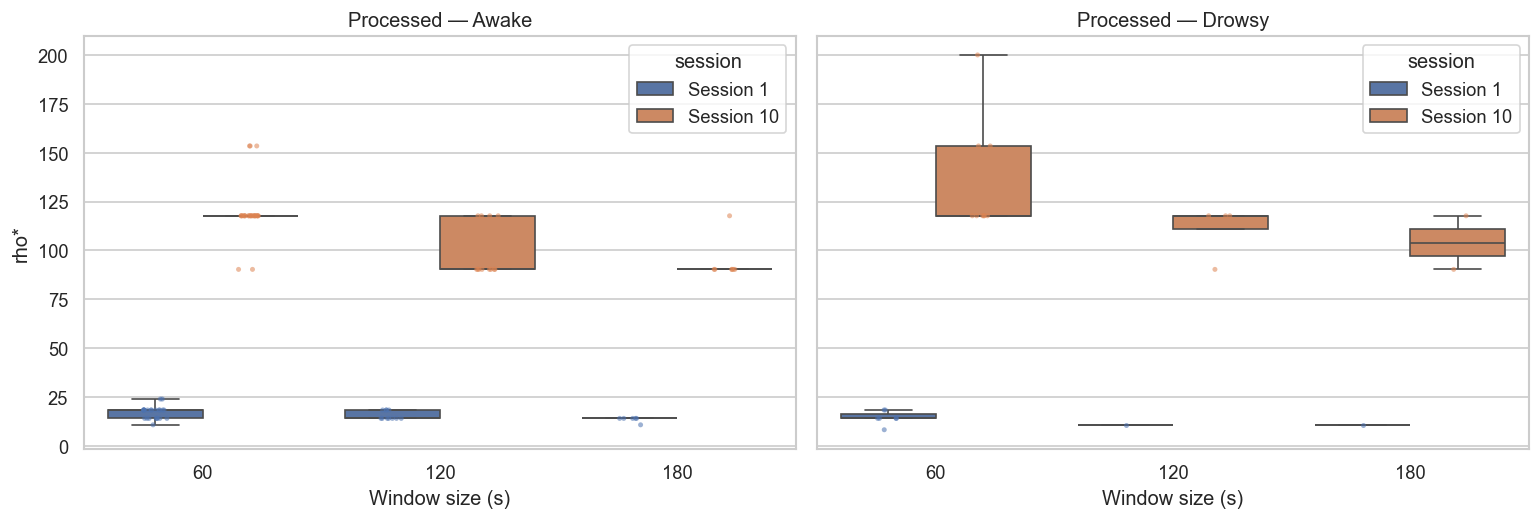

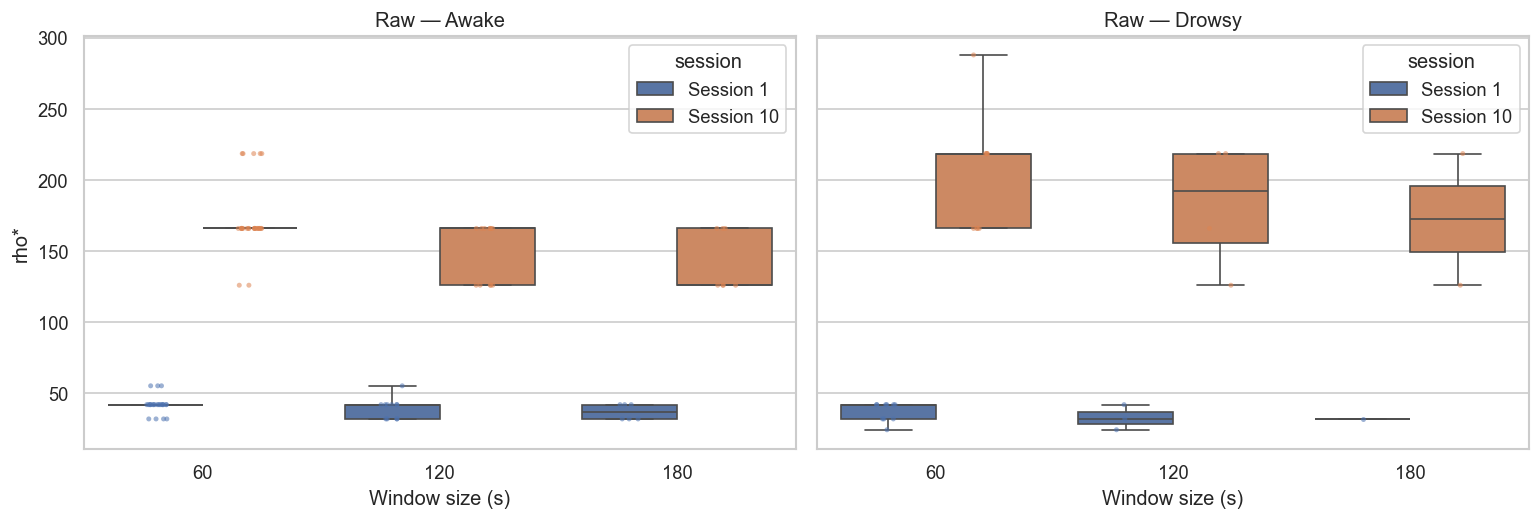

In [8]:
# TASK 8 - Plot absolute rho distributions
for representation in REPRESENTATIONS:
    subset = rho_results[
        rho_results["representation"] == representation
    ]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for axis, state in zip(axes, STATE_NAMES.values()):
        state_data = subset[subset["state"] == state]
        sns.boxplot(
            data=state_data,
            x="window_size",
            y="rho_star",
            hue="session",
            showfliers=False,
            ax=axis,
        )
        sns.stripplot(
            data=state_data,
            x="window_size",
            y="rho_star",
            hue="session",
            dodge=True,
            alpha=0.55,
            size=3,
            legend=False,
            ax=axis,
        )
        axis.set_title(f"{representation} — {state}")
        axis.set_xlabel("Window size (s)")
        axis.set_ylabel("rho*")
    fig.tight_layout()
    plt.show()


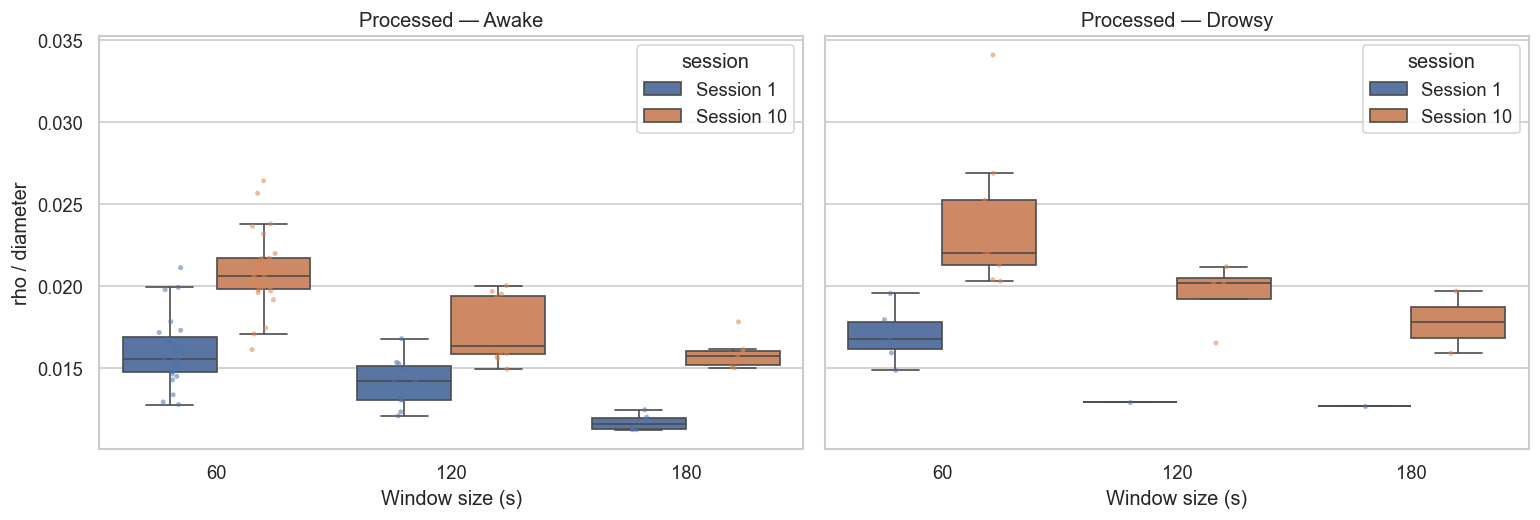

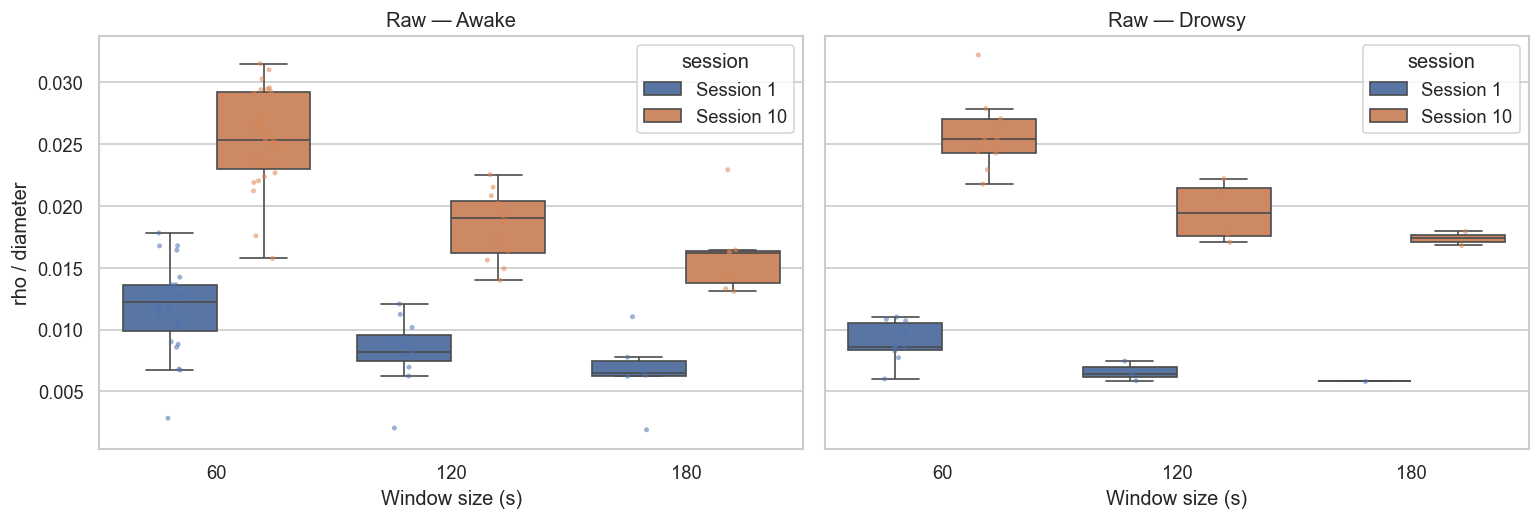

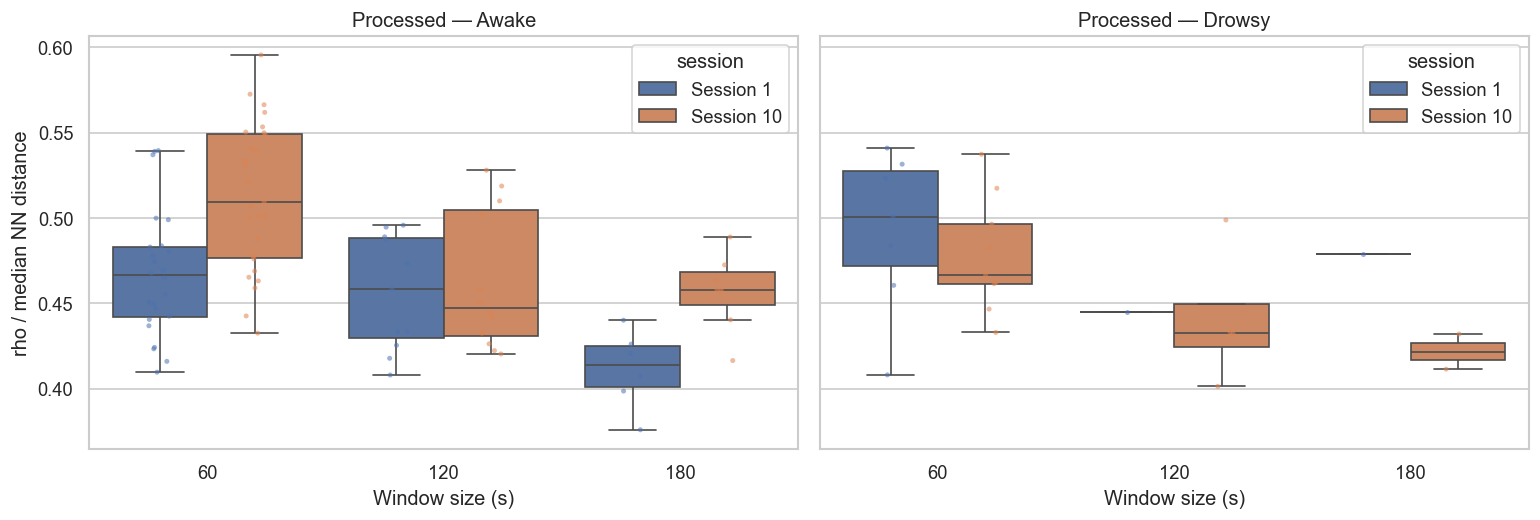

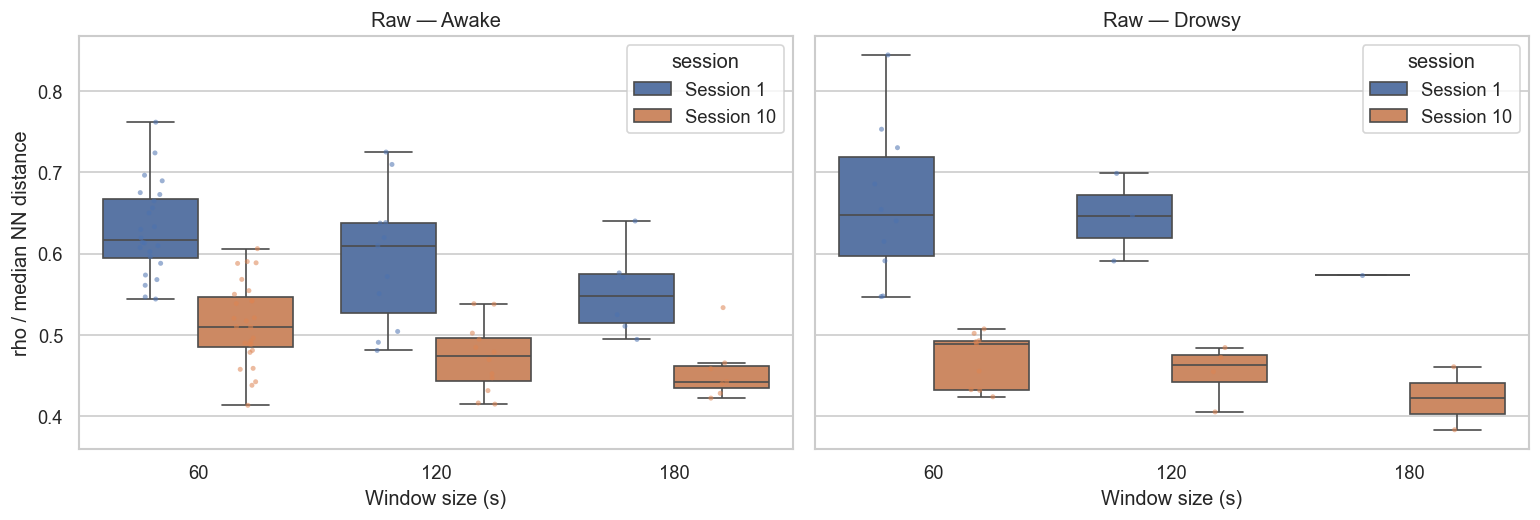

In [9]:
# TASK 9 - Plot geometry-normalized rho distributions
def plot_normalized_distribution(metric, label):
    '''Plot one normalized rho metric by representation and state.'''
    for representation in REPRESENTATIONS:
        subset = rho_results[
            rho_results["representation"] == representation
        ]
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
        for axis, state in zip(axes, STATE_NAMES.values()):
            state_data = subset[subset["state"] == state]
            sns.boxplot(
                data=state_data,
                x="window_size",
                y=metric,
                hue="session",
                showfliers=False,
                ax=axis,
            )
            sns.stripplot(
                data=state_data,
                x="window_size",
                y=metric,
                hue="session",
                dodge=True,
                alpha=0.55,
                size=3,
                legend=False,
                ax=axis,
            )
            axis.set_title(f"{representation} — {state}")
            axis.set_xlabel("Window size (s)")
            axis.set_ylabel(label)
        fig.tight_layout()
        plt.show()


plot_normalized_distribution("rho_D", "rho / diameter")
plot_normalized_distribution("rho_NN", "rho / median NN distance")


In [10]:
# TASK 10 - Group stability table
def coefficient_of_variation(values):
    '''Return sample CV when the mean is nonzero.'''
    mean = np.mean(values)
    if len(values) < 2 or np.isclose(mean, 0.0):
        return 0.0
    return float(np.std(values, ddof=1) / abs(mean))


def robust_cv(values):
    '''Return IQR divided by the absolute median.'''
    median = np.median(values)
    if np.isclose(median, 0.0):
        return 0.0
    return float(iqr(values) / abs(median))


group_stability = (
    rho_results.groupby(
        ["representation", "state", "window_size", "session"],
        as_index=False,
    )
    .agg(
        N=("rho_star", "size"),
        median_rho=("rho_star", "median"),
        IQR_rho=("rho_star", iqr),
        CV_rho=("rho_star", coefficient_of_variation),
        robust_CV_rho=("rho_star", robust_cv),
        median_rho_NN=("rho_NN", "median"),
        IQR_rho_NN=("rho_NN", iqr),
        robust_CV_rho_NN=("rho_NN", robust_cv),
    )
)
group_stability


,representation,state,window_size,session,N,median_rho,IQR_rho,CV_rho,robust_CV_rho,median_rho_NN,IQR_rho_NN,robust_CV_rho_NN
0,Processed,Awake,60,Session 1,24,18.431747,4.289611,0.183516,0.232730,0.466287,0.041139,0.088227
1,Processed,Awake,60,Session 10,27,117.740804,0.000000,0.118469,0.000000,0.509472,0.072483,0.142271
2,Processed,Awake,120,Session 1,11,14.142136,4.289611,0.137831,0.303321,0.458579,0.058743,0.128098
3,Processed,Awake,120,Session 10,12,90.339045,27.401758,0.135632,0.303321,0.447225,0.073536,0.164427
4,Processed,Awake,180,Session 1,6,14.142136,0.000000,0.098845,0.000000,0.413887,0.023942,0.057848
5,Processed,Awake,180,Session 10,7,90.339045,0.000000,0.109883,0.000000,0.457824,0.019126,0.041777
6,Processed,Drowsy,60,Session 1,7,14.142136,2.144806,0.234199,0.151661,0.500693,0.055280,0.110406
7,Processed,Drowsy,60,Session 10,9,117.740804,35.713296,0.214548,0.303321,0.466325,0.034835,0.074702
8,Processed,Drowsy,120,Session 1,1,10.850843,0.000000,0.000000,0.000000,0.444814,0.000000,0.000000
9,Processed,Drowsy,120,Session 10,4,117.740804,6.850440,0.123553,0.058182,0.432602,0.025296,0.058474


In [11]:
# TASK 11 - Session-to-session replication
def relative_difference(first, second):
    '''Return absolute difference relative to the pair mean.'''
    denominator = (abs(first) + abs(second)) / 2
    if np.isclose(denominator, 0.0):
        return 0.0
    return float(abs(first - second) / denominator)


session_rows = []
for keys, group in rho_results.groupby(
    ["representation", "state", "window_size"]
):
    medians = group.groupby("session")[["rho_star", "rho_NN"]].median()
    first = medians.loc[SESSION_NAMES[SESSIONS[0]]]
    second = medians.loc[SESSION_NAMES[SESSIONS[1]]]
    session_rows.append(
        {
            "representation": keys[0],
            "state": keys[1],
            "window_size": keys[2],
            "median_session_1": first["rho_star"],
            "median_session_2": second["rho_star"],
            "relative_difference_rho": relative_difference(
                first["rho_star"], second["rho_star"]
            ),
            "median_rho_NN_session_1": first["rho_NN"],
            "median_rho_NN_session_2": second["rho_NN"],
            "relative_difference_rho_NN": relative_difference(
                first["rho_NN"], second["rho_NN"]
            ),
        }
    )
session_replication = pd.DataFrame(session_rows)
session_replication


,representation,state,window_size,median_session_1,median_session_2,relative_difference_rho,median_rho_NN_session_1,median_rho_NN_session_2,relative_difference_rho_NN
0,Processed,Awake,60,18.431747,117.740804,1.458577,0.466287,0.509472,0.088515
1,Processed,Awake,120,14.142136,90.339045,1.458577,0.458579,0.447225,0.025069
2,Processed,Awake,180,14.142136,90.339045,1.458577,0.413887,0.457824,0.100807
3,Processed,Drowsy,60,14.142136,117.740804,1.571070,0.500693,0.466325,0.071082
4,Processed,Drowsy,120,10.850843,117.740804,1.662471,0.444814,0.432602,0.027837
5,Processed,Drowsy,180,10.850843,104.039924,1.622221,0.478641,0.421682,0.126531
6,Raw,Awake,60,41.677053,165.722701,1.196199,0.616290,0.510104,0.188540
7,Raw,Awake,120,41.677053,165.722701,1.196199,0.609480,0.474273,0.249518
8,Raw,Awake,180,36.649915,125.743343,1.097255,0.547713,0.442654,0.212161
9,Raw,Drowsy,60,41.677053,218.413261,1.359037,0.647133,0.489026,0.278318


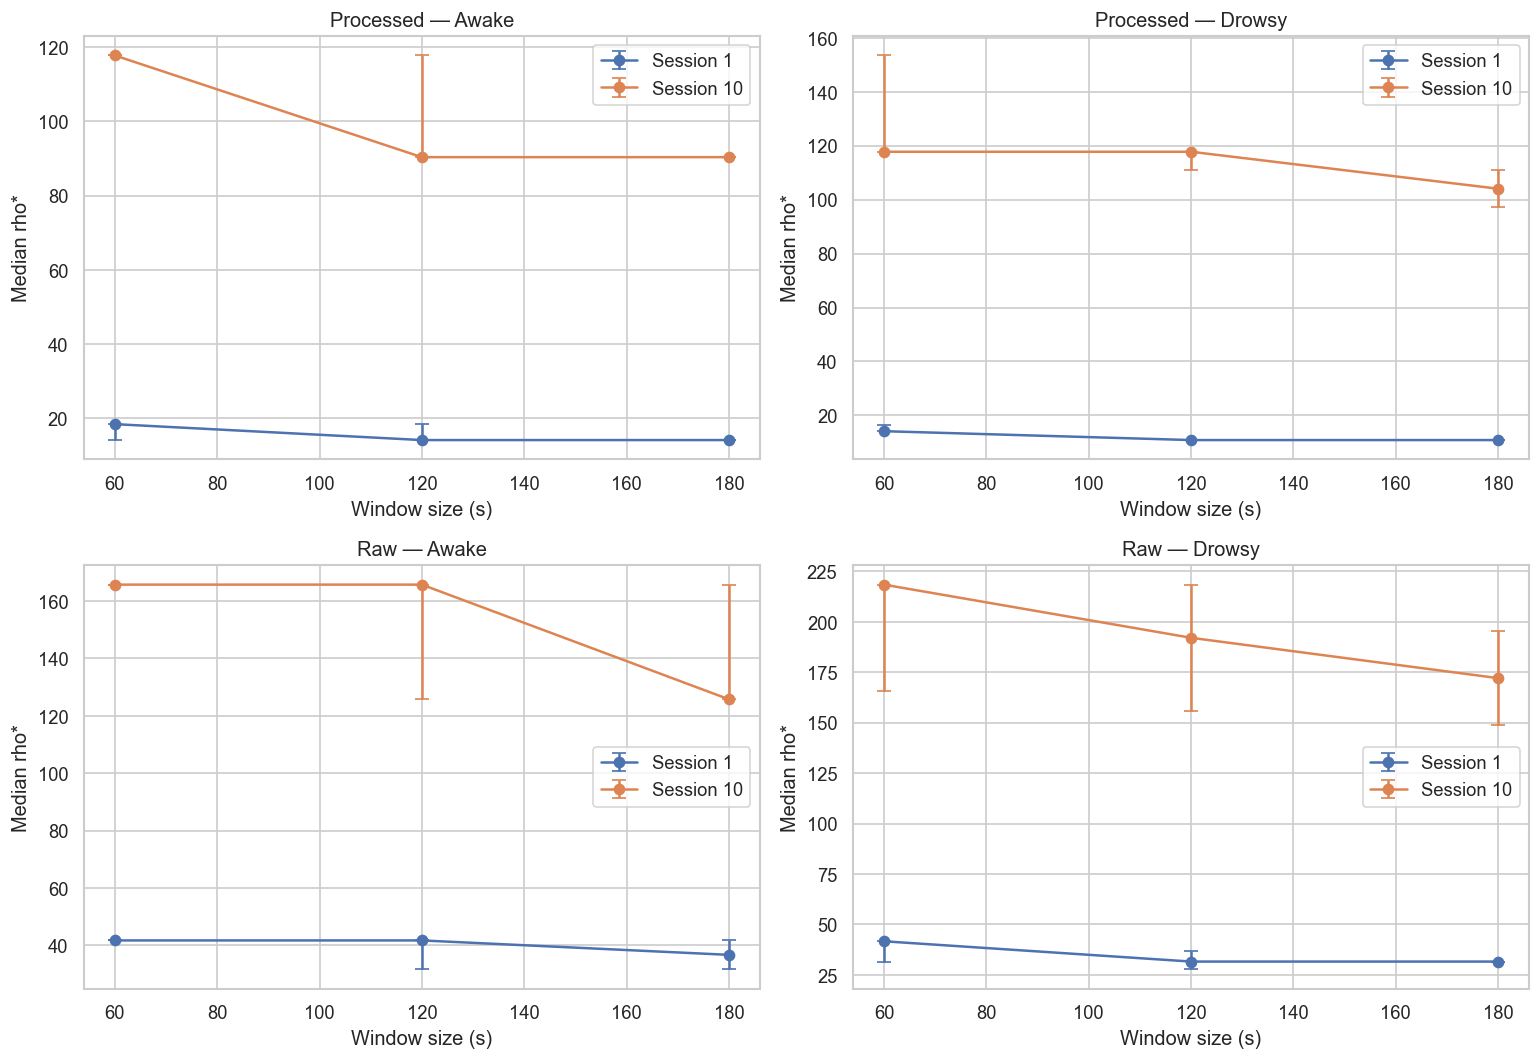

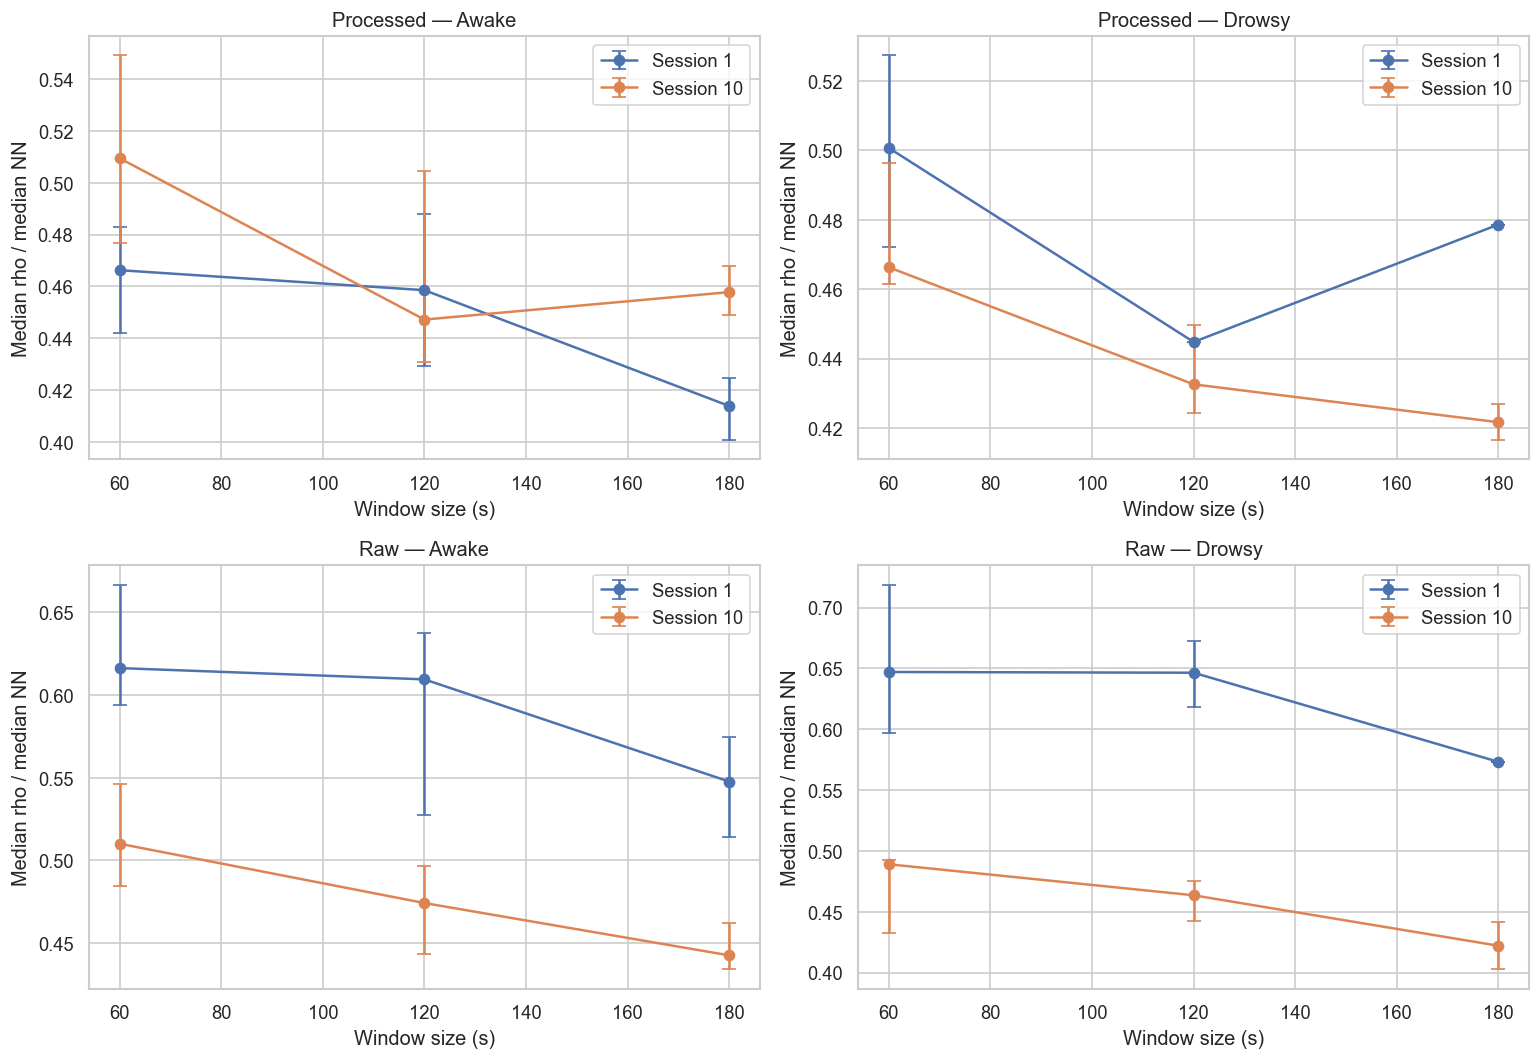

,session,representation,state,window_size,median_rho,q25_rho,q75_rho,median_rho_NN,q25_rho_NN,q75_rho_NN
0,Session 1,Processed,Awake,60,18.431747,14.142136,18.431747,0.466287,0.441956,0.483095
1,Session 1,Processed,Awake,120,14.142136,14.142136,18.431747,0.458579,0.429351,0.488094
2,Session 1,Processed,Awake,180,14.142136,14.142136,14.142136,0.413887,0.400728,0.424671
3,Session 1,Processed,Drowsy,60,14.142136,14.142136,16.286941,0.500693,0.472104,0.527384
4,Session 1,Processed,Drowsy,120,10.850843,10.850843,10.850843,0.444814,0.444814,0.444814
5,Session 1,Processed,Drowsy,180,10.850843,10.850843,10.850843,0.478641,0.478641,0.478641
6,Session 1,Raw,Awake,60,41.677053,41.677053,41.677053,0.616290,0.594006,0.666745
7,Session 1,Raw,Awake,120,41.677053,31.622777,41.677053,0.609480,0.527471,0.637705
8,Session 1,Raw,Awake,180,36.649915,31.622777,41.677053,0.547713,0.514189,0.574769
9,Session 1,Raw,Drowsy,60,41.677053,31.622777,41.677053,0.647133,0.596949,0.718955


In [12]:
# TASK 12 - Window-size stability
window_size_summary = (
    rho_results.groupby(
        ["session", "representation", "state", "window_size"],
        as_index=False,
    )
    .agg(
        median_rho=("rho_star", "median"),
        q25_rho=("rho_star", lambda x: np.quantile(x, 0.25)),
        q75_rho=("rho_star", lambda x: np.quantile(x, 0.75)),
        median_rho_NN=("rho_NN", "median"),
        q25_rho_NN=("rho_NN", lambda x: np.quantile(x, 0.25)),
        q75_rho_NN=("rho_NN", lambda x: np.quantile(x, 0.75)),
    )
)

for metric, lower, upper, ylabel in (
    ("median_rho", "q25_rho", "q75_rho", "Median rho*"),
    (
        "median_rho_NN",
        "q25_rho_NN",
        "q75_rho_NN",
        "Median rho / median NN",
    ),
):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for axis, representation, state in zip(
        axes.flat,
        np.repeat(REPRESENTATIONS, 2),
        list(STATE_NAMES.values()) * 2,
    ):
        subset = window_size_summary[
            (window_size_summary["representation"] == representation)
            & (window_size_summary["state"] == state)
        ]
        for session, group in subset.groupby("session"):
            group = group.sort_values("window_size")
            y_error = np.vstack(
                (
                    group[metric] - group[lower],
                    group[upper] - group[metric],
                )
            )
            axis.errorbar(
                group["window_size"],
                group[metric],
                yerr=y_error,
                marker="o",
                capsize=4,
                label=session,
            )
        axis.set_title(f"{representation} — {state}")
        axis.set_xlabel("Window size (s)")
        axis.set_ylabel(ylabel)
        axis.legend()
    fig.tight_layout()
    plt.show()

window_size_summary


In [13]:
# TASK 13 - Awake versus Drowsy stability
state_rows = []
for keys, group in rho_results.groupby(
    ["session", "representation", "window_size"]
):
    medians = group.groupby("state")[["rho_star", "rho_NN"]].median()
    awake = medians.loc["Awake"]
    drowsy = medians.loc["Drowsy"]
    state_rows.append(
        {
            "session": keys[0],
            "representation": keys[1],
            "window_size": keys[2],
            "median_rho_awake": awake["rho_star"],
            "median_rho_drowsy": drowsy["rho_star"],
            "relative_difference_rho": relative_difference(
                awake["rho_star"], drowsy["rho_star"]
            ),
            "median_rho_NN_awake": awake["rho_NN"],
            "median_rho_NN_drowsy": drowsy["rho_NN"],
            "relative_difference_rho_NN": relative_difference(
                awake["rho_NN"], drowsy["rho_NN"]
            ),
        }
    )
state_stability = pd.DataFrame(state_rows)
state_stability


,session,representation,window_size,median_rho_awake,median_rho_drowsy,relative_difference_rho,median_rho_NN_awake,median_rho_NN_drowsy,relative_difference_rho_NN
0,Session 1,Processed,60,18.431747,14.142136,0.263377,0.466287,0.500693,0.071162
1,Session 1,Processed,120,14.142136,10.850843,0.263377,0.458579,0.444814,0.030473
2,Session 1,Processed,180,14.142136,10.850843,0.263377,0.413887,0.478641,0.145104
3,Session 1,Raw,60,41.677053,41.677053,0.000000,0.616290,0.647133,0.048825
4,Session 1,Raw,120,41.677053,31.622777,0.274333,0.609480,0.646525,0.058988
5,Session 1,Raw,180,36.649915,31.622777,0.147266,0.547713,0.573257,0.045575
6,Session 10,Processed,60,117.740804,117.740804,0.000000,0.509472,0.466325,0.088436
7,Session 10,Processed,120,90.339045,117.740804,0.263377,0.447225,0.432602,0.033241
8,Session 10,Processed,180,90.339045,104.039924,0.140971,0.457824,0.421682,0.082187
9,Session 10,Raw,60,165.722701,218.413261,0.274333,0.510104,0.489026,0.042194


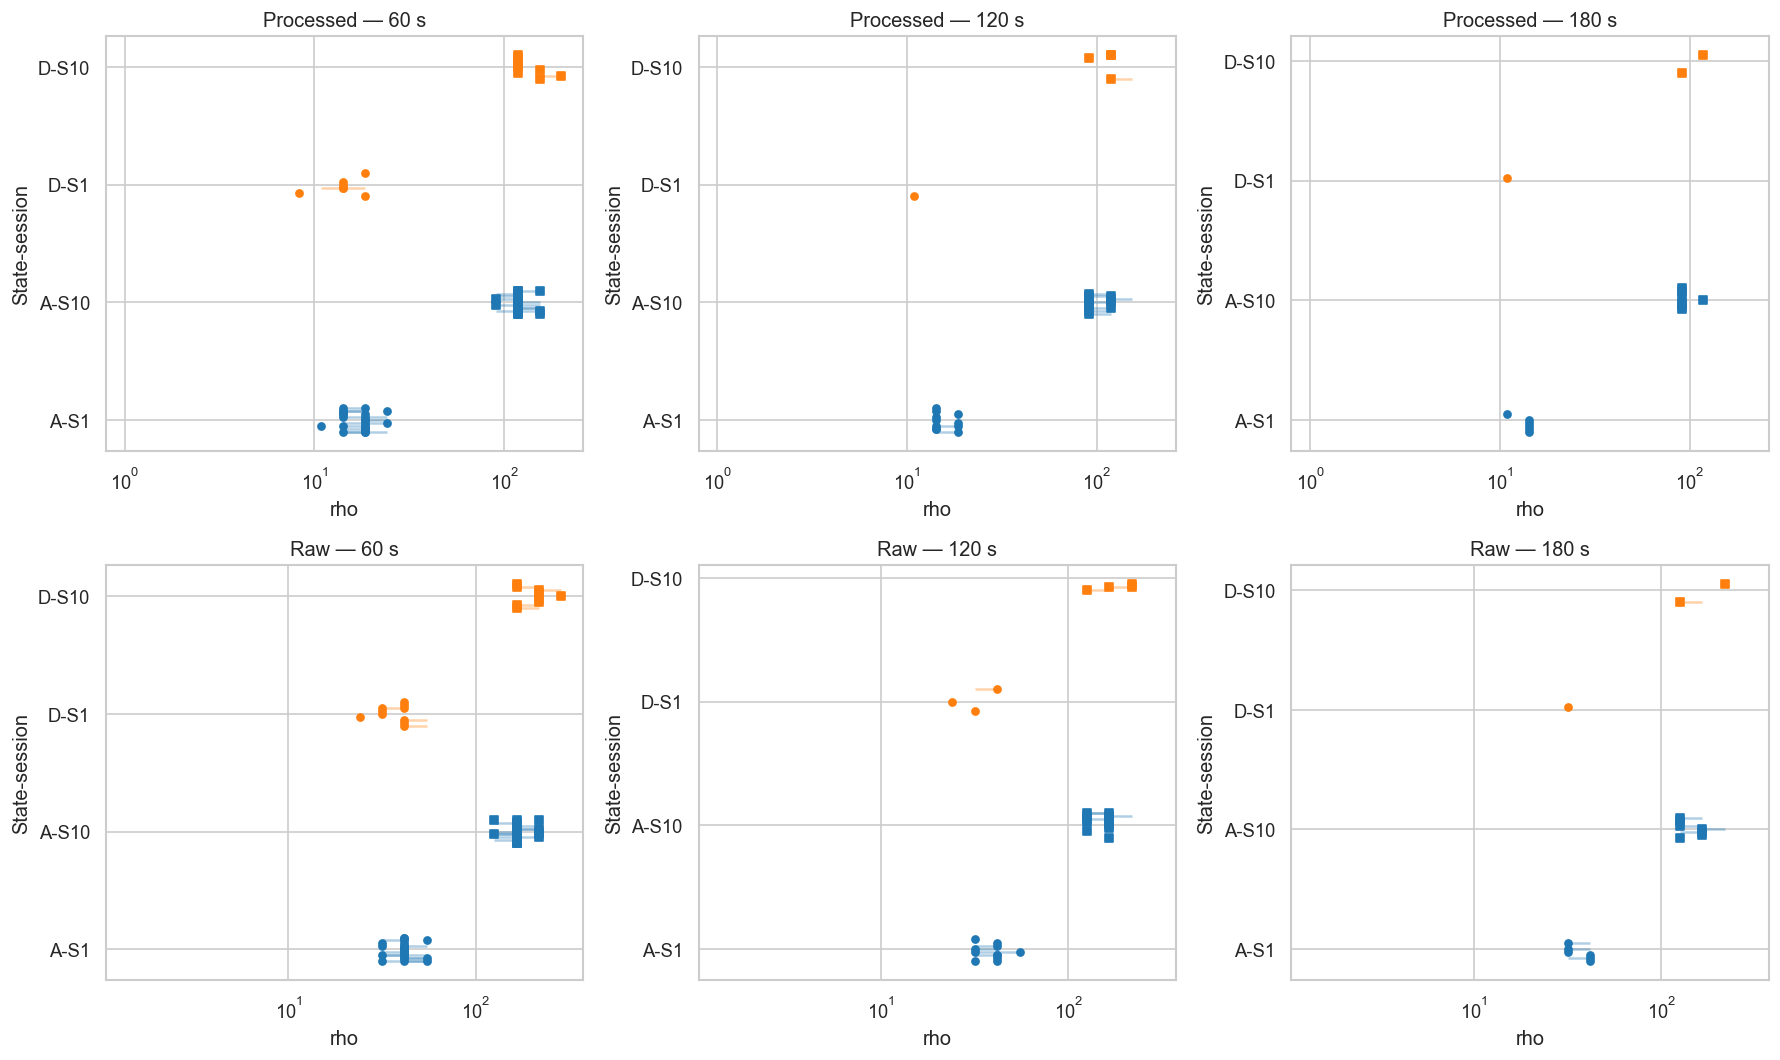

,session,representation,state,window_size,window_id,rho_star,rho_low_95,rho_high_95,peak_width_ratio
0,Session 1,Processed,Awake,60,1,18.431747,18.431747,24.022489,1.303321
1,Session 1,Processed,Awake,60,2,18.431747,18.431747,18.431747,1.000000
2,Session 1,Processed,Awake,60,3,18.431747,18.431747,18.431747,1.000000
3,Session 1,Processed,Awake,60,4,18.431747,14.142136,18.431747,1.303321
4,Session 1,Processed,Awake,60,5,18.431747,18.431747,18.431747,1.000000
...,...,...,...,...,...,...,...,...,...
222,Session 10,Raw,Awake,180,5,165.722701,165.722701,165.722701,1.000000
223,Session 10,Raw,Awake,180,6,165.722701,125.743343,165.722701,1.317944
224,Session 10,Raw,Awake,180,7,165.722701,165.722701,218.413261,1.317944
225,Session 10,Raw,Awake,180,8,125.743343,125.743343,165.722701,1.317944


In [14]:
# TASK 14 - Peak-width and plateau stability
def peak_interval(row):
    '''Return the contiguous 95% plateau around the selected peak.'''
    rho = row["rho_candidates"]
    counts = row["mean_counts"]
    peak_index = int(row["best_index"])
    threshold = PLATEAU_FRACTION * counts[peak_index]
    left = peak_index
    right = peak_index
    while left > 0 and counts[left - 1] >= threshold:
        left -= 1
    while right < len(counts) - 1 and counts[right + 1] >= threshold:
        right += 1
    return pd.Series(
        {
            "rho_low_95": float(rho[left]),
            "rho_high_95": float(rho[right]),
            "peak_width_ratio": float(rho[right] / rho[left]),
        }
    )


plateau_values = rho_results.apply(peak_interval, axis=1)
rho_results = pd.concat([rho_results, plateau_values], axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex="row")
colors = {"Awake": "tab:blue", "Drowsy": "tab:orange"}
markers = {"Session 1": "o", "Session 10": "s"}
for axis, representation, window_size in zip(
    axes.flat,
    np.repeat(REPRESENTATIONS, len(WINDOW_SIZES)),
    WINDOW_SIZES * len(REPRESENTATIONS),
):
    subset = rho_results[
        (rho_results["representation"] == representation)
        & (rho_results["window_size"] == window_size)
    ].reset_index(drop=True)
    bases = {
        ("Awake", "Session 1"): 0,
        ("Awake", "Session 10"): 1,
        ("Drowsy", "Session 1"): 2,
        ("Drowsy", "Session 10"): 3,
    }
    for index, row in subset.iterrows():
        base = bases[(row["state"], row["session"])]
        jitter = ((index % 9) - 4) * 0.025
        y_value = base + jitter
        axis.hlines(
            y_value,
            row["rho_low_95"],
            row["rho_high_95"],
            color=colors[row["state"]],
            alpha=0.35,
        )
        axis.scatter(
            row["rho_star"],
            y_value,
            color=colors[row["state"]],
            marker=markers[row["session"]],
            s=18,
        )
    axis.set_xscale("log")
    axis.set_yticks(range(4))
    axis.set_yticklabels(
        ["A-S1", "A-S10", "D-S1", "D-S10"]
    )
    axis.set_title(f"{representation} — {window_size} s")
    axis.set_xlabel("rho")
    axis.set_ylabel("State-session")
fig.tight_layout()
plt.show()

rho_results[
    result_keys
    + ["rho_star", "rho_low_95", "rho_high_95", "peak_width_ratio"]
]


In [15]:
# TASK 15 - Define and summarize candidate freeze hierarchy
FREEZE_SCHEMES = OrderedDict(
    {
        "Level 1: global": [],
        "Level 2: representation": ["representation"],
        "Level 3: representation-state": [
            "representation",
            "state",
        ],
        "Level 4: representation-window": [
            "representation",
            "window_size",
        ],
        "Level 5: representation-state-window": [
            "representation",
            "state",
            "window_size",
        ],
        "Level 6: window-specific": result_keys,
    }
)


def grouped_frames(dataframe, columns):
    '''Yield group name and frame, including the global scheme.'''
    if not columns:
        yield "All windows", dataframe
        return
    for keys, group in dataframe.groupby(columns, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        label = "; ".join(
            f"{column}={value}"
            for column, value in zip(columns, keys)
        )
        yield label, group


hierarchy_rows = []
for scheme, columns in FREEZE_SCHEMES.items():
    group_cvs = []
    for _, group in grouped_frames(rho_results, columns):
        group_cvs.append(robust_cv(group["rho_star"].to_numpy()))
    hierarchy_rows.append(
        {
            "freeze_scheme": scheme,
            "n_groups": len(group_cvs),
            "median_group_robust_CV": np.median(group_cvs),
            "max_group_robust_CV": np.max(group_cvs),
        }
    )
freeze_hierarchy = pd.DataFrame(hierarchy_rows)
freeze_hierarchy


,freeze_scheme,n_groups,median_group_robust_CV,max_group_robust_CV
0,Level 1: global,1,1.041859,1.041859
1,Level 2: representation,2,1.066637,1.146776
2,Level 3: representation-state,4,1.054767,1.405531
3,Level 4: representation-window,6,0.881370,0.986499
4,Level 5: representation-state-window,12,0.861671,3.608483
5,Level 6: window-specific,227,0.000000,0.000000


In [16]:
# TASK 16 - Frozen-rho plateau coverage
coverage_rows = []
scheme_assignments = {}
for scheme, columns in FREEZE_SCHEMES.items():
    assigned = pd.Series(index=rho_results.index, dtype=float)
    for group_label, group in grouped_frames(rho_results, columns):
        frozen_rho = float(group["rho_star"].median())
        covered = (
            (group["rho_low_95"] <= frozen_rho)
            & (frozen_rho <= group["rho_high_95"])
        )
        assigned.loc[group.index] = frozen_rho
        coverage_rows.append(
            {
                "freeze_scheme": scheme,
                "group": group_label,
                "frozen_rho": frozen_rho,
                "N_windows": len(group),
                "plateau_coverage": covered.mean(),
            }
        )
    scheme_assignments[scheme] = assigned

coverage_table = pd.DataFrame(coverage_rows)
scheme_summary_rows = []
for scheme in FREEZE_SCHEMES:
    assigned = scheme_assignments[scheme]
    covered = (
        (rho_results["rho_low_95"] <= assigned)
        & (assigned <= rho_results["rho_high_95"])
    )
    group_coverages = coverage_table.loc[
        coverage_table["freeze_scheme"] == scheme,
        "plateau_coverage",
    ]
    scheme_summary_rows.append(
        {
            "freeze_scheme": scheme,
            "overall_coverage": covered.mean(),
            "minimum_group_coverage": group_coverages.min(),
        }
    )
freeze_scheme_summary = pd.DataFrame(scheme_summary_rows)

representation_recommendations = {}
candidate_schemes = list(FREEZE_SCHEMES)[1:]
for representation in REPRESENTATIONS:
    selected_index = rho_results.index[
        rho_results["representation"] == representation
    ]
    recommendation = candidate_schemes[-1]
    for scheme in candidate_schemes:
        assigned = scheme_assignments[scheme].loc[selected_index]
        subset = rho_results.loc[selected_index]
        coverage = (
            (subset["rho_low_95"] <= assigned)
            & (assigned <= subset["rho_high_95"])
        ).mean()
        if coverage >= COVERAGE_TARGET:
            recommendation = scheme
            break
    representation_recommendations[representation] = recommendation

display(coverage_table)
display(freeze_scheme_summary)
pd.DataFrame(
    representation_recommendations.items(),
    columns=["representation", "recommended_scheme"],
)


,freeze_scheme,group,frozen_rho,N_windows,plateau_coverage
0,Level 1: global,All windows,90.339045,227,0.105727
1,Level 2: representation,representation=Processed,90.339045,111,0.216216
2,Level 2: representation,representation=Raw,125.743343,116,0.172414
3,Level 3: representation-state,representation=Processed; state=Awake,90.339045,87,0.252874
4,Level 3: representation-state,representation=Processed; state=Drowsy,117.740804,24,0.416667
...,...,...,...,...,...
247,Level 6: window-specific,session=Session 10; representation=Raw; state=...,165.722701,1,1.000000
248,Level 6: window-specific,session=Session 10; representation=Raw; state=...,218.413261,1,1.000000
249,Level 6: window-specific,session=Session 10; representation=Raw; state=...,218.413261,1,1.000000
250,Level 6: window-specific,session=Session 10; representation=Raw; state=...,125.743343,1,1.000000


,freeze_scheme,overall_coverage,minimum_group_coverage
0,Level 1: global,0.105727,0.105727
1,Level 2: representation,0.193833,0.172414
2,Level 3: representation-state,0.229075,0.068966
3,Level 4: representation-window,0.308370,0.100000
4,Level 5: representation-state-window,0.259912,0.098039
5,Level 6: window-specific,1.000000,1.000000


,representation,recommended_scheme
0,Processed,Level 6: window-specific
1,Raw,Level 6: window-specific


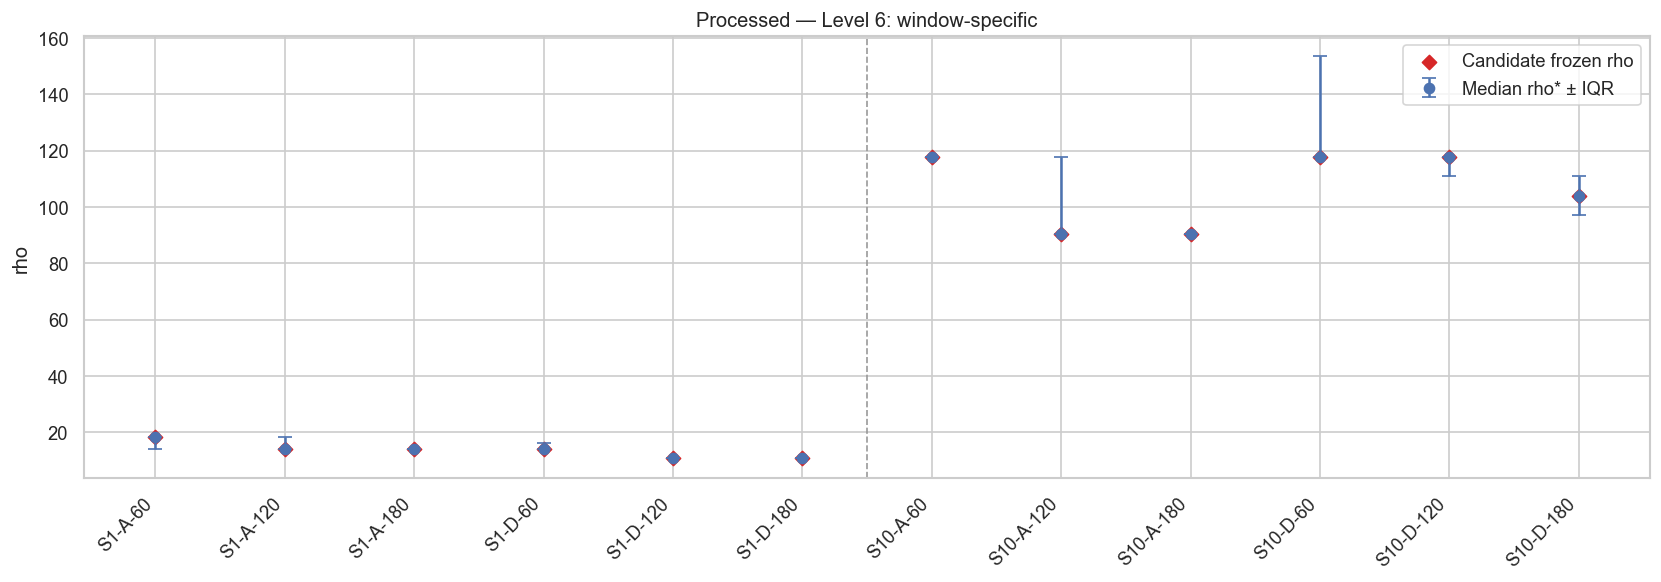

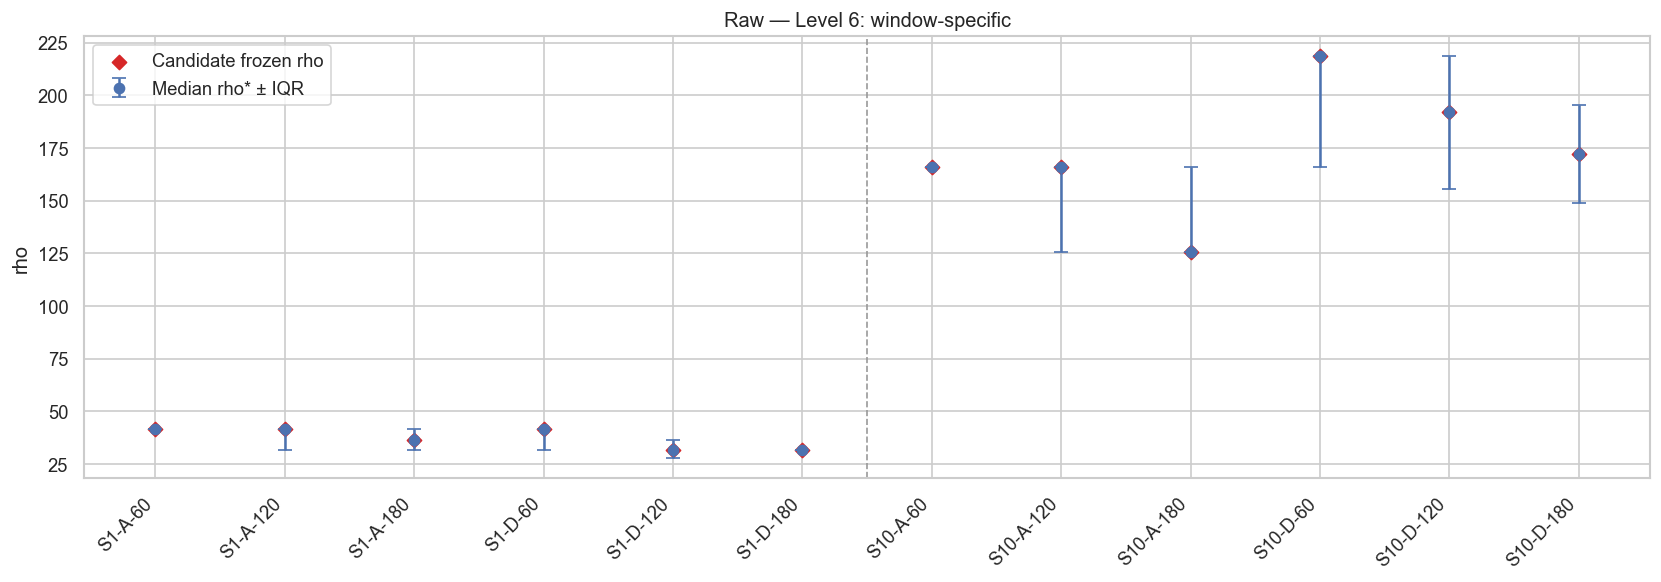

In [17]:
# TASK 17 - Final summary figures with candidate frozen rho
summary_groups = (
    rho_results.groupby(
        ["representation", "state", "window_size", "session"],
        as_index=False,
    )
    .agg(
        median_rho=("rho_star", "median"),
        q25_rho=("rho_star", lambda x: np.quantile(x, 0.25)),
        q75_rho=("rho_star", lambda x: np.quantile(x, 0.75)),
    )
)

for representation in REPRESENTATIONS:
    scheme = representation_recommendations[representation]
    assigned = scheme_assignments[scheme]
    subset_results = rho_results[
        rho_results["representation"] == representation
    ].copy()
    subset_results["candidate_frozen_rho"] = assigned.loc[
        subset_results.index
    ]
    frozen_groups = (
        subset_results.groupby(
            ["state", "window_size", "session"],
            as_index=False,
        )["candidate_frozen_rho"]
        .median()
    )
    plot_data = summary_groups[
        summary_groups["representation"] == representation
    ].merge(
        frozen_groups,
        on=["state", "window_size", "session"],
        validate="one_to_one",
    )
    session_rank = plot_data["session"].map(
        {"Session 1": 0, "Session 10": 1}
    )
    state_rank = plot_data["state"].map(
        {"Awake": 0, "Drowsy": 1}
    )
    plot_data = (
        plot_data.assign(
            session_rank=session_rank,
            state_rank=state_rank,
        )
        .sort_values(["session_rank", "state_rank", "window_size"])
        .reset_index(drop=True)
    )
    plot_data["label"] = (
        plot_data["session"].str.replace("Session ", "S")
        + "-"
        + plot_data["state"].str[0]
        + "-"
        + plot_data["window_size"].astype(str)
    )
    positions = np.arange(len(plot_data))
    lower = plot_data["median_rho"] - plot_data["q25_rho"]
    upper = plot_data["q75_rho"] - plot_data["median_rho"]
    fig, axis = plt.subplots(figsize=(14, 5))
    axis.errorbar(
        positions,
        plot_data["median_rho"],
        yerr=np.vstack((lower, upper)),
        fmt="o",
        capsize=4,
        label="Median rho* ± IQR",
    )
    axis.scatter(
        positions,
        plot_data["candidate_frozen_rho"],
        marker="D",
        color="tab:red",
        label="Candidate frozen rho",
    )
    session_1_count = plot_data["session"].eq("Session 1").sum()
    axis.axvline(
        session_1_count - 0.5,
        color="0.6",
        linestyle="--",
        linewidth=1,
    )
    axis.set_xticks(positions)
    axis.set_xticklabels(plot_data["label"], rotation=45, ha="right")
    axis.set_ylabel("rho")
    axis.set_title(f"{representation} — {scheme}")
    axis.legend()
    fig.tight_layout()
    plt.show()


In [18]:
# TASK 18 - Final decision table
def representation_coverage(representation, scheme):
    '''Return plateau coverage for one representation and scheme.'''
    selected = rho_results["representation"] == representation
    subset = rho_results.loc[selected]
    assigned = scheme_assignments[scheme].loc[selected]
    return float(
        (
            (subset["rho_low_95"] <= assigned)
            & (assigned <= subset["rho_high_95"])
        ).mean()
    )


decision_rows = []
for representation in REPRESENTATIONS:
    coverage_representation = representation_coverage(
        representation, "Level 2: representation"
    )
    coverage_state = representation_coverage(
        representation, "Level 3: representation-state"
    )
    coverage_window = representation_coverage(
        representation, "Level 4: representation-window"
    )
    coverage_state_window = representation_coverage(
        representation,
        "Level 5: representation-state-window",
    )
    replication = session_replication[
        session_replication["representation"] == representation
    ]
    session_replicated = bool(
        replication["relative_difference_rho"].median()
        <= SESSION_SHIFT_LIMIT
    )
    raw_dispersion = group_stability.loc[
        group_stability["representation"] == representation,
        "robust_CV_rho",
    ].median()
    normalized_dispersion = group_stability.loc[
        group_stability["representation"] == representation,
        "robust_CV_rho_NN",
    ].median()
    decision_rows.append(
        {
            "representation": representation,
            "state_pooling": (
                "YES" if coverage_representation >= COVERAGE_TARGET else "NO"
            ),
            "window_size_pooling": (
                "YES"
                if max(coverage_representation, coverage_state)
                >= COVERAGE_TARGET
                else "NO"
            ),
            "session_replication": "YES" if session_replicated else "NO",
            "coverage_representation": coverage_representation,
            "coverage_state": coverage_state,
            "coverage_window": coverage_window,
            "coverage_state_window": coverage_state_window,
            "median_robust_CV_rho": raw_dispersion,
            "median_robust_CV_rho_NN": normalized_dispersion,
            "more_stable_scale": (
                "rho_NN"
                if normalized_dispersion < raw_dispersion
                else "absolute rho"
            ),
            "recommended_freeze": (
                representation_recommendations[representation]
            ),
        }
    )

final_decision_table = pd.DataFrame(decision_rows)
final_decision_table


,representation,state_pooling,window_size_pooling,session_replication,coverage_representation,coverage_state,coverage_window,coverage_state_window,median_robust_CV_rho,median_robust_CV_rho_NN,more_stable_scale,recommended_freeze
0,Processed,NO,NO,NO,0.216216,0.288288,0.450450,0.288288,0.094936,0.066588,rho_NN,Level 6: window-specific
1,Raw,NO,NO,NO,0.172414,0.172414,0.172414,0.232759,0.241242,0.111336,rho_NN,Level 6: window-specific


## Tổng hợp kết quả thực nghiệm

### Dữ liệu và cấu hình

- Hai session: `Session 1` và `Session 10`.
- Tổng số cửa sổ: `227`, gồm `105` cửa sổ Session 1 và `122` cửa sổ Session 10.
- Session 1 gồm `50` Processed và `55` Raw; Session 10 gồm `61` Processed và `61` Raw.
- Window size: `60`, `120`, `180` giây; trạng thái: Awake và Drowsy.
- Embedding dimension `m=8`; Processed dùng `tau=0.16 s`, Raw dùng `tau=0.20 s`.
- Processed rho grid: `1–200`; Raw rho grid: `2–500`; mỗi grid có `21` điểm logarithmic và `3` trial cho mỗi rho.

### QC rho optimization

- Số boundary optima: `1/227`; boundary fraction tổng thể: `0.0044`.
- Boundary optimum xuất hiện trong nhóm Session 10, Processed, Drowsy, 60 giây: `1/9` cửa sổ.

### Median rho và rho_NN theo nhóm

| Session | Representation | State | Window (s) | N | Median rho | IQR rho | Median rho_NN | IQR rho_NN |
|---|---|---|---:|---:|---:|---:|---:|---:|
| Session 1 | Processed | Awake | 60 | 24 | 18.431747 | 4.289611 | 0.466287 | 0.041139 |
| Session 1 | Processed | Awake | 120 | 11 | 14.142136 | 4.289611 | 0.458579 | 0.058743 |
| Session 1 | Processed | Awake | 180 | 6 | 14.142136 | 0.000000 | 0.413887 | 0.023942 |
| Session 1 | Processed | Drowsy | 60 | 7 | 14.142136 | 2.144806 | 0.500693 | 0.055280 |
| Session 1 | Processed | Drowsy | 120 | 1 | 10.850843 | 0.000000 | 0.444814 | 0.000000 |
| Session 1 | Processed | Drowsy | 180 | 1 | 10.850843 | 0.000000 | 0.478641 | 0.000000 |
| Session 1 | Raw | Awake | 60 | 24 | 41.677053 | 0.000000 | 0.616290 | 0.072739 |
| Session 1 | Raw | Awake | 120 | 11 | 41.677053 | 10.054276 | 0.609480 | 0.110234 |
| Session 1 | Raw | Awake | 180 | 6 | 36.649915 | 10.054276 | 0.547713 | 0.060580 |
| Session 1 | Raw | Drowsy | 60 | 10 | 41.677053 | 10.054276 | 0.647133 | 0.122006 |
| Session 1 | Raw | Drowsy | 120 | 3 | 31.622777 | 8.841517 | 0.646525 | 0.053848 |
| Session 1 | Raw | Drowsy | 180 | 1 | 31.622777 | 0.000000 | 0.573257 | 0.000000 |
| Session 10 | Processed | Awake | 60 | 27 | 117.740804 | 0.000000 | 0.509472 | 0.072483 |
| Session 10 | Processed | Awake | 120 | 12 | 90.339045 | 27.401758 | 0.447225 | 0.073536 |
| Session 10 | Processed | Awake | 180 | 7 | 90.339045 | 0.000000 | 0.457824 | 0.019126 |
| Session 10 | Processed | Drowsy | 60 | 9 | 117.740804 | 35.713296 | 0.466325 | 0.034835 |
| Session 10 | Processed | Drowsy | 120 | 4 | 117.740804 | 6.850440 | 0.432602 | 0.025296 |
| Session 10 | Processed | Drowsy | 180 | 2 | 104.039924 | 13.700879 | 0.421682 | 0.010274 |
| Session 10 | Raw | Awake | 60 | 27 | 165.722701 | 0.000000 | 0.510104 | 0.061290 |
| Session 10 | Raw | Awake | 120 | 12 | 165.722701 | 39.979358 | 0.474273 | 0.053150 |
| Session 10 | Raw | Awake | 180 | 7 | 125.743343 | 39.979358 | 0.442654 | 0.027746 |
| Session 10 | Raw | Drowsy | 60 | 9 | 218.413261 | 52.690560 | 0.489026 | 0.060205 |
| Session 10 | Raw | Drowsy | 120 | 4 | 192.067981 | 62.685400 | 0.463542 | 0.032958 |
| Session 10 | Raw | Drowsy | 180 | 2 | 172.078302 | 46.334959 | 0.422069 | 0.038716 |

### Session-to-session relative difference

| Representation | State | Window (s) | Relative difference rho | Relative difference rho_NN |
|---|---|---:|---:|---:|
| Processed | Awake | 60 | 1.458577 | 0.088515 |
| Processed | Awake | 120 | 1.458577 | 0.025069 |
| Processed | Awake | 180 | 1.458577 | 0.100807 |
| Processed | Drowsy | 60 | 1.571070 | 0.071082 |
| Processed | Drowsy | 120 | 1.662471 | 0.027837 |
| Processed | Drowsy | 180 | 1.622221 | 0.126531 |
| Raw | Awake | 60 | 1.196199 | 0.188540 |
| Raw | Awake | 120 | 1.196199 | 0.249518 |
| Raw | Awake | 180 | 1.097255 | 0.212161 |
| Raw | Drowsy | 60 | 1.359037 | 0.278318 |
| Raw | Drowsy | 120 | 1.434527 | 0.329679 |
| Raw | Drowsy | 180 | 1.379036 | 0.303794 |

### Plateau coverage của freeze hierarchy

| Freeze scheme | Overall coverage | Minimum group coverage |
|---|---:|---:|
| Level 1: global | 0.105727 | 0.105727 |
| Level 2: representation | 0.193833 | 0.172414 |
| Level 3: representation-state | 0.229075 | 0.068966 |
| Level 4: representation-window | 0.308370 | 0.100000 |
| Level 5: representation-state-window | 0.259912 | 0.098039 |
| Level 6: window-specific | 1.000000 | 1.000000 |

### Kết quả bảng quyết định cuối

| Representation | State pooling | Window-size pooling | Session replication | Median robust CV rho | Median robust CV rho_NN | Scale ghi nhận ổn định hơn | Recommended freeze |
|---|---|---|---|---:|---:|---|---|
| Processed | NO | NO | NO | 0.094936 | 0.066588 | rho_NN | Level 6: window-specific |
| Raw | NO | NO | NO | 0.241242 | 0.111336 | rho_NN | Level 6: window-specific |